In [1]:
import pandas as pd
import geopandas as gpd

/home/simonhans/anaconda3/envs/GrapeExpectations/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [2]:
gdb_path = '../data/soil/extract/gSSURGO_WA.gdb'

vine_path = '../data/polygons/RegressionRidge.geojson'
vine_poly = gpd.read_file(vine_path)

vine_smol_path = '../data/polygons/RegressionRidge_smol.geojson'
vine_smol_poly = gpd.read_file(vine_smol_path)

In [3]:
vine_poly = vine_poly.to_crs('EPSG:5070')
vine_smol_poly = vine_smol_poly.to_crs('EPSG:5070')

bbox = tuple(vine_poly.total_bounds)

soils_subset = gpd.read_file(
    gdb_path,
    layer='MUPOLYGON',
    bbox=bbox
)

soils_clipped = gpd.clip(soils_subset, vine_poly)
# soils_clipped.to_file('soils_vineyard.gpkg', driver='GPKG')

In [4]:
soil_exploded = soils_clipped.explode(index_parts=False)

soil_clipped_to_vine = gpd.clip(soil_exploded, vine_poly)

soil_clipped_to_plot = gpd.clip(soil_exploded, vine_smol_poly)

soil_final = soils_clipped.dissolve(by='MUKEY', as_index=False)

In [5]:
import matplotlib.pyplot as plt

In [6]:
target_crs = 'EPSG:32610'

vine_smol_poly = vine_smol_poly.to_crs(target_crs)
soil_proj = soil_clipped_to_plot.to_crs(target_crs)


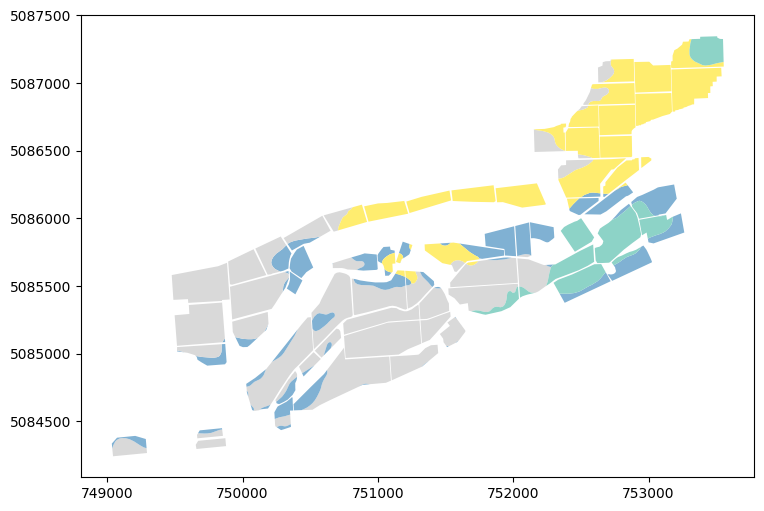

In [7]:

fig, ax = plt.subplots(figsize=(10, 6))

# Plot soil polygons colored by MUKEY
soil_proj.plot(
    ax=ax, 
    column='MUKEY',
    cmap='Set3',
    edgecolor='black',
    alpha=1,
    linewidth=0,
    # legend=True,
    legend_kwds={'title': 'MUKEY'}
)

# Plot vineyard outline on top
vine_smol_poly.plot(
    ax=ax,
    color='none',
    edgecolor='red',
    linewidth=0
)
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')

# plt.xticks([])
# plt.yticks([])




In [8]:
elev_feats = pd.read_pickle('../data/plot_elev_features.pkl')

In [9]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

dem_path = '../data/DEM/RegressionRidge_DEM.tif'
dem_utm_path = '../data/DEM/RegressionRidge_DEM_utm.tif'  

# Reproject DEM to UTM (meters)
with rasterio.open(dem_path) as src:
    if src.crs.to_epsg() != 32610:  #
        dst_crs = 'EPSG:32610'
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })
        
        
        # save a copy of projection for later loading
        with rasterio.open(dem_utm_path, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.bilinear
                )
        dem_file = dem_utm_path
    else:
        dem_file = dem_path

In [10]:
# Load DEM
with rasterio.open(dem_file) as src:
    dem = src.read(1)   
    transform = src.transform
    nodata = src.nodata
    xres = transform.a
    yres = transform.e

In [11]:
import numpy as np

# mask nodata
dem = np.where(dem == nodata, np.nan, dem)

In [12]:
# compute slope and aspect
dy, dx = np.gradient(dem, abs(yres), abs(xres))

dxx, dxy = np.gradient(dx, abs(yres), abs(xres))
dyx, dyy = np.gradient(dy, abs(yres), abs(xres)) 

curvature = dxx + dyy 
profile_curv = (
    (dxx * dx**2 + 2 * dxy * dx * dy + dyy * dy**2)
    / ((dx**2 + dy**2) * (1 + dx**2 + dy**2)**1.5 + 1e-9)
)

plan_curv = (
    (dxx * dy**2 - 2 * dxy * dx * dy + dyy * dx**2)
    / ((dx**2 + dy**2) * (1 + dx**2 + dy**2)**0.5 + 1e-9)
)
# slope in degrees
slope_deg = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))

# aspect in degrees, 0 = north
aspect_rad = np.arctan2(-dx, dy)
aspect_deg = (np.degrees(aspect_rad) + 360) % 360

# elevation deviation
elev_dev = dem - np.nanmean(dem)

/home/simonhans/anaconda3/envs/GrapeExpectations/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in remainder


In [13]:
import geopandas as gpd
import pandas as pd
vineyard_path = '../data/polygons/RegressionRidge.geojson'
# plots_path = '../data/polygons/RegressionRidge_smol.geojson'
plots_path = '../data/polygons/RegressionRidge_smol_smol.pkl'

# Load vineyard polygons
vineyard = gpd.read_file(vineyard_path)
vineyard = vineyard.to_crs(crs=rasterio.open(dem_file).crs)
# vineyard.plot()

# Load plot polygons
plots = pd.read_pickle(plots_path)
plots = plots.to_crs(crs=rasterio.open(dem_file).crs)
# plots.plot()

In [14]:
from rasterstats import zonal_stats
import pandas as pd


def calculate_elevation_statistics(gdf):
    # Compute zonal stats
    slope_stats = zonal_stats(gdf, slope_deg, affine=transform, nodata=np.nan,
                              stats=['mean', 'min', 'max'])
    aspect_stats = zonal_stats(gdf, aspect_deg, affine=transform, nodata=np.nan,
                               stats=['mean', 'min', 'max'])
    
    elev_stats = zonal_stats(gdf, dem, affine=transform, nodata=np.nan,
                             stats=['mean', 'min', 'max'])
    
    elev_dev_stats = zonal_stats(gdf, elev_dev, affine=transform, nodata=np.nan,
                             stats=['mean', 'min', 'max'])
    
    curv_stats = zonal_stats(gdf, curvature, affine=transform, nodata=np.nan,
                         stats=['mean', 'min', 'max'])
    
    profile_curv_stats = zonal_stats(gdf, profile_curv, affine=transform, nodata=np.nan,
                         stats=['mean', 'min', 'max'])

    
    plan_curv_stats = curv_stats = zonal_stats(gdf, plan_curv, affine=transform, nodata=np.nan,
                         stats=['mean', 'min', 'max'])


    # Combine into dataframe
    df_features = pd.DataFrame({
        'plot_id': [s for s in gdf['plot_id'].values],
        'slope_mean': [s['mean'] for s in slope_stats],
        'slope_min': [s['min'] for s in slope_stats],
        'slope_max': [s['max'] for s in slope_stats],
        
        'curve_mean': [s['mean'] for s in curv_stats],
        'curve_min': [s['min'] for s in curv_stats],
        'curve_max': [s['max'] for s in curv_stats],
        
        'pro_curve_mean': [s['mean'] for s in profile_curv_stats],
        'pro_curve_min': [s['min'] for s in profile_curv_stats],
        'pro_curve_max': [s['max'] for s in profile_curv_stats],
        
        'plan_curve_mean': [s['mean'] for s in plan_curv_stats],
        'plan_curve_min': [s['min'] for s in plan_curv_stats],
        'plan_curve_max': [s['max'] for s in plan_curv_stats],
        
        
        'aspect_mean': [s['mean'] for s in aspect_stats],
        'aspect_min': [s['min'] for s in aspect_stats],
        'aspect_max': [s['max'] for s in aspect_stats],
        'elev_min': [s['min'] for s in elev_stats],
        'elev_max': [s['max'] for s in elev_stats],
        'elev_mean': [s['mean'] for s in elev_stats],
        'elev_dev_min': [s['min'] for s in elev_dev_stats],
        'elev_dev_max': [s['max'] for s in elev_dev_stats],
        'elev_dev_mean': [s['mean'] for s in elev_dev_stats]
    })

    df_features = df_features.merge(gdf, how = 'inner', on = 'plot_id')
    df_features['total_relief'] = df_features['elev_max'] - df_features['elev_min']

    gdf_features = gpd.GeoDataFrame(df_features, geometry=gdf.geometry, crs=gdf.crs)
    return gdf_features


plot_features = calculate_elevation_statistics(plots)

In [15]:
gdf_features = gpd.GeoDataFrame(
    plot_features,
    geometry=plot_features['geometry'], 
    crs=rasterio.open(dem_file).crs
)

In [16]:
# compute area in square meters
gdf_features['area_m2'] = gdf_features.geometry.area

# convert to hectares -- commonly used in agg
gdf_features['area_ha'] = gdf_features['area_m2'] / 10000

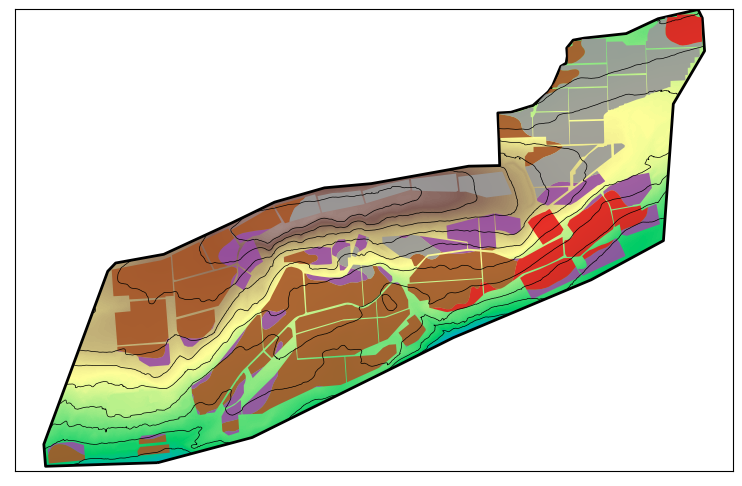

In [40]:
import matplotlib.pyplot as plt

with rasterio.open(dem_file) as src:
    dem = src.read(1, masked=True)
    raster_crs = src.crs
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    

fig, ax = plt.subplots(figsize=(10, 6))

# DEM
im = ax.imshow(
    dem,
    extent=extent,
    origin='upper',
    cmap='terrain',
    vmin=25,
    vmax=350
)

# # # create a new axes for the left colorbar [left, bottom, width, height]
# cbar_ax_left = fig.add_axes([-0.008, 0.15, 0.02, 0.7])  # tweak numbers as needed
# cbar_dem = fig.colorbar(im, cax=cbar_ax_left)
# cbar_dem.set_label('Elevation (m)', fontsize=15)
# cbar_dem.ax.tick_params(labelsize=12)

# vineyard
vineyard.plot(ax=ax, facecolor='none', edgecolor='k', linewidth=2)

# plot features without legend
# gdf_features = gdf_features.copy()
# gdf_features.plot(
#     ax=ax,
#     column='slope_max',
#     cmap='cividis',
#     # vmin = 
#     legend=False,
#     alpha=1,
#     edgecolor='black',
#     # linewidth=0.5
# )

# slope colorbar on the right (default)
sm = plt.cm.ScalarMappable(
    cmap='cividis',
    norm=plt.Normalize(vmin=plot_features['slope_max'].min(),
                       vmax=plot_features['slope_max'].max())
)

# Plot soil polygons colored by MUKEY
soil_proj.plot(
    ax=ax, 
    column='MUKEY',
    cmap='Set1',
    edgecolor='black',
    alpha=0.9,
    linewidth=0,
    # legend=True,
    legend_kwds={'title': 'MUKEY'}
)

# Create coordinate grids matching your extent
x = np.linspace(extent[0], extent[1], dem.shape[1])
y = np.linspace(extent[3], extent[2], dem.shape[0])  # notice extent[3] -> extent[2]
X, Y = np.meshgrid(x, y)


# Add contour lines on top of the image
contours = ax.contour(
    X,Y, dem,
    levels=10,      # number of contours or provide a list of elevations
    colors='black', # contour line color
    linewidths=0.5
)
# sm._A = []
# cbar_aspect = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.04)
# cbar_aspect.set_label('Max Slope (degrees)', fontsize=15)
# cbar_aspect.ax.tick_params(labelsize=12)

# fig.suptitle('Regression Ridge\nClipped DEM with Max Slope', fontsize = 18)
# ax.set_xlabel('Longitude', fontsize = 15)
# ax.set_ylabel('Latitude', fontsize = 15)
ax.set_xticks([])
ax.set_yticks([])
plt.savefig('../img/dem_soil_contour.png')
# plt.show()


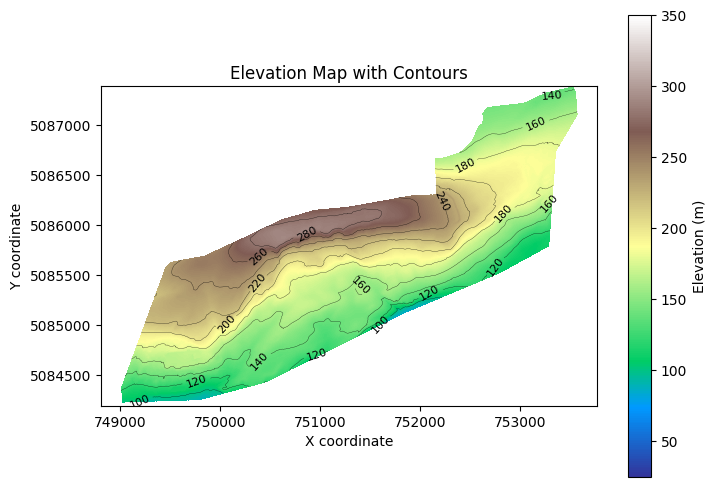

In [34]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8,6))

# Show DEM image
im = ax.imshow(
    dem,
    extent=extent,   # [xmin, xmax, ymin, ymax]
    origin='upper',
    cmap='terrain',
    vmin=25,
    vmax=350
)

# Optional: add a colorbar
cbar = plt.colorbar(im, ax=ax, label='Elevation (m)')

# Create coordinate grids matching your extent
x = np.linspace(extent[0], extent[1], dem.shape[1])
y = np.linspace(extent[3], extent[2], dem.shape[0])  # notice extent[3] -> extent[2]
X, Y = np.meshgrid(x, y)


# Add contour lines on top of the image
contours = ax.contour(
    X,Y, dem,
    levels=10,      # number of contours or provide a list of elevations
    colors='black', # contour line color
    linewidths=0.2
)

# Add contour labels
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

ax.set_title("Elevation Map with Contours")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")

plt.show()
